In [17]:
import tensorflow
from tensorflow.keras import layers,models


# Inception A(basic)

In [18]:
x=layers.Input(shape=(35,35,192))

In [19]:
br1_conv_1=layers.Conv2D(64,(1,1),activation='relu',padding='same')(x)
br2_conv_1=layers.Conv2D(48,(1,1),activation='relu',padding='same')(x)
br2_conv_2=layers.Conv2D(64,(3,3),activation='relu',padding='same')(br2_conv_1)
br3_conv_1=layers.Conv2D(64,(1,1),activation='relu',padding='same')(x)
br3_conv_2=layers.Conv2D(96,(3,3),activation='relu',padding='same')(br3_conv_1)
br3_conv_3=layers.Conv2D(96,(3,3),activation='relu',padding='same')(br3_conv_2)
avg_pool=layers.AveragePooling2D((3,3),strides=1,padding='same')(x)
br4_conv4=layers.Conv2D(32,(1,1),activation='relu',padding='same')(avg_pool)
output=layers.Concatenate(axis=-1)([br1_conv_1,br2_conv_2,br3_conv_3,br4_conv4])

In [20]:
model=models.Model(inputs=x,outputs=output)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 35, 35,    │          0 │ -                 │
│ (InputLayer)        │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 35, 35,    │     12,352 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 35, 35,    │      9,264 │ input_layer_5[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 35, 35,    │     55,392 │ conv2d_70[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_7 │ (None, 35, 35,    │          0 │ input_layer_5[0]… │
│ (AveragePooling2D)  │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 35, 35,    │     12,352 │ input_layer_5[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 35, 35,    │     27,712 │ conv2d_68[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 35, 35,    │     83,040 │ conv2d_71[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 35, 35,    │      6,176 │ average_pooling2… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 35, 35,    │          0 │ conv2d_67[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_69[0][0],  │
│                     │                   │            │ conv2d_72[0][0],  │
│                     │                   │            │ conv2d_73[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 206,288 (805.81 KB)

 Trainable params: 206,288 (805.81 KB)

 Non-trainable params: 0 (0.00 B)

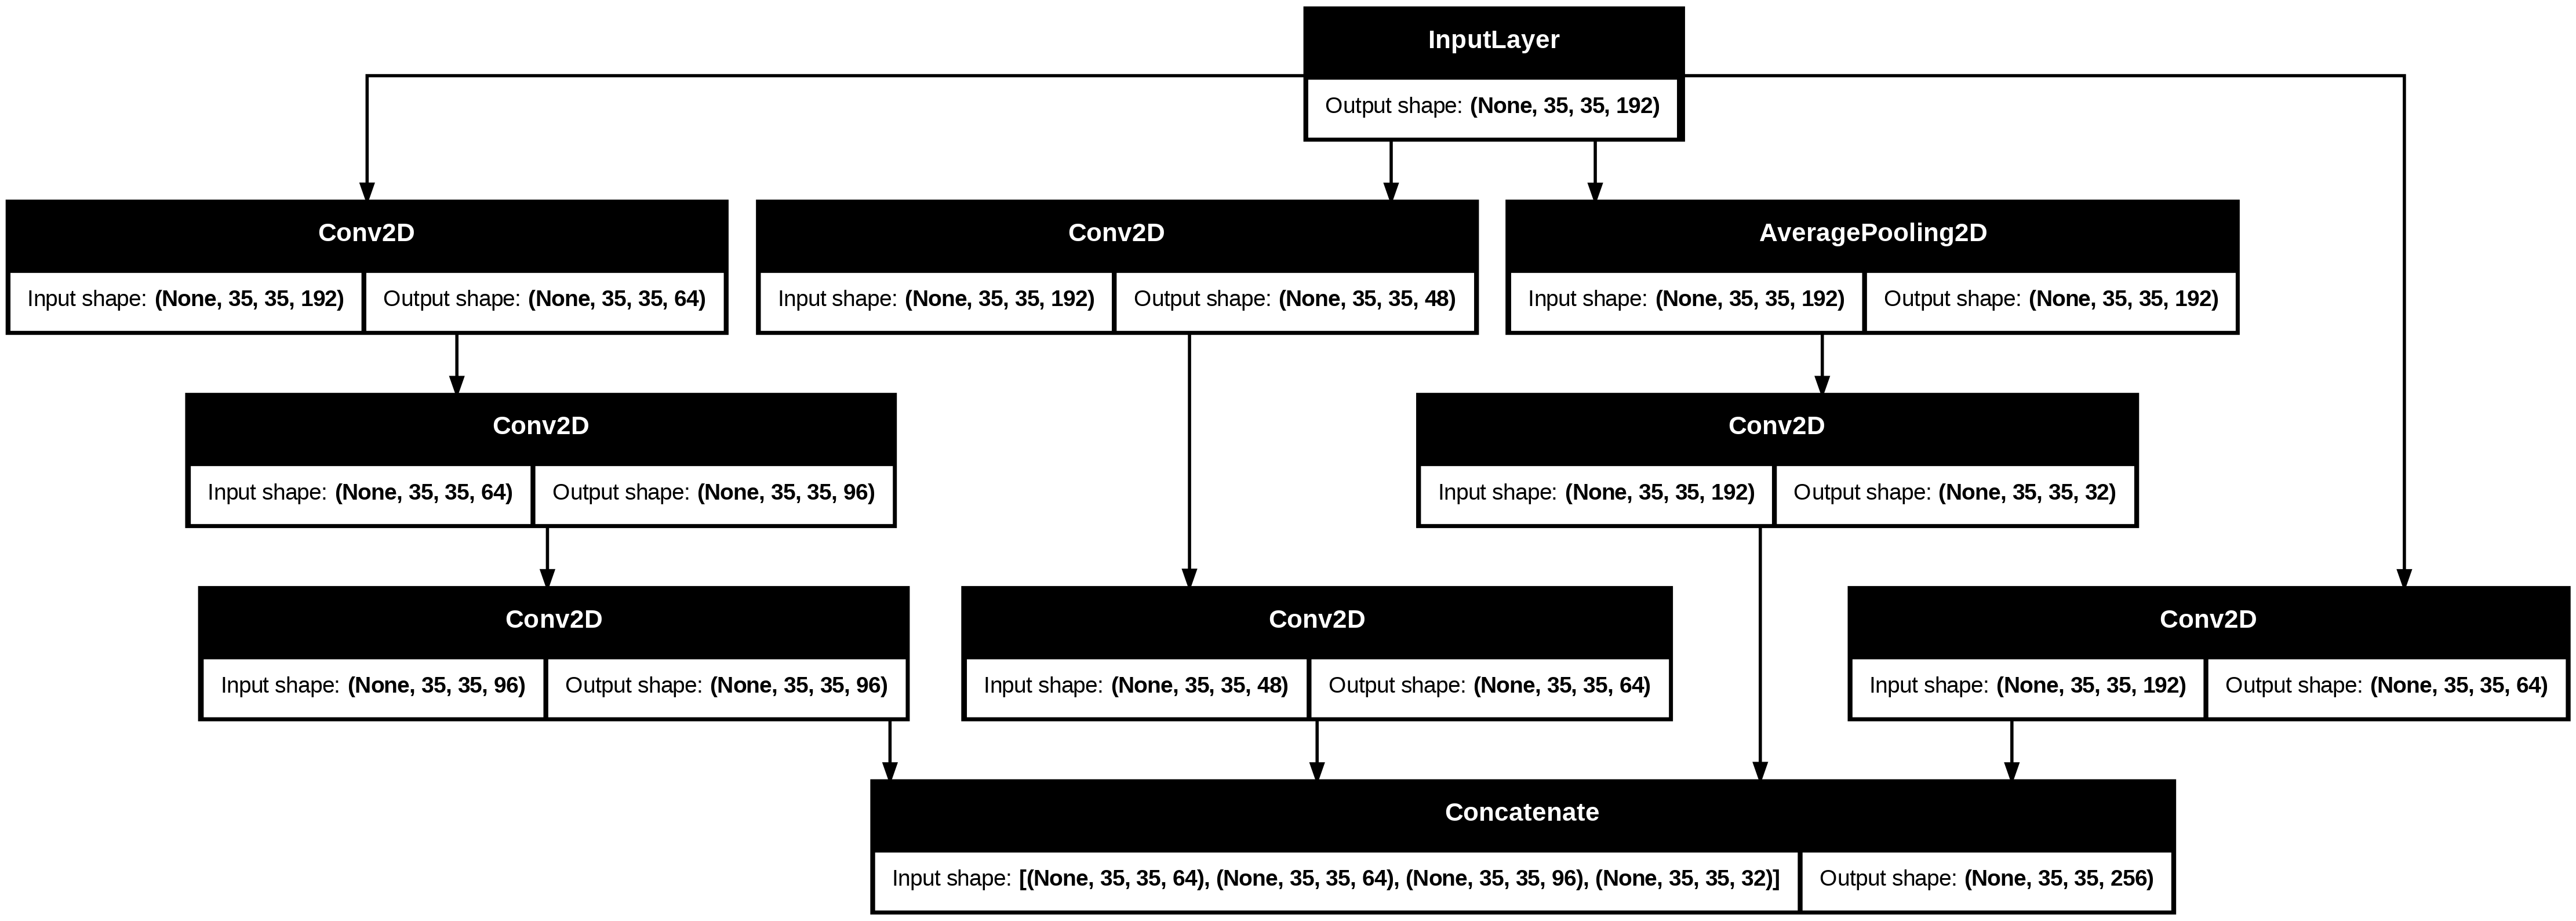

In [21]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)

In [22]:
def conv_bn(x, filters, kernel_size):
    x = layers.Conv2D(filters, kernel_size,
                      padding='same',
                      use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def inception_A(x):

    # Branch 1
    br1 = conv_bn(x, 64, (1,1))

    # Branch 2
    br2 = conv_bn(x, 48, (1,1))
    br2 = conv_bn(br2, 64, (3,3))

    # Branch 3
    br3 = conv_bn(x, 64, (1,1))
    br3 = conv_bn(br3, 96, (3,3))
    br3 = conv_bn(br3, 96, (3,3))

    # Branch 4
    br4 = layers.AveragePooling2D((3,3), strides=1, padding='same')(x)
    br4 = conv_bn(br4, 32, (1,1))

    x = layers.Concatenate(axis=-1)([br1, br2, br3, br4])

    return x

#REDUCTION A

In [23]:
y=layers.Input(shape=(35,35,256))
conv1=layers.Conv2D(384,(3,3),strides=2,padding='valid',activation='relu')(y)
conv2=layers.Conv2D(64,(1,1),padding='same',activation='relu')(y)
conv3=layers.Conv2D(96,(3,3),padding='same',activation='relu')(conv2)
conv4=layers.Conv2D(96,(3,3),padding='valid',activation='relu',strides=2)(conv3)
padd1=layers.MaxPool2D((3,3),strides=2,padding='valid')(y)
output=layers.Concatenate(axis=-1)([conv1,conv4,padd1])

In [24]:
model1=models.Model(inputs=y,outputs=output)

In [25]:
model1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 35, 35,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 35, 35,    │     16,448 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 35, 35,    │     55,392 │ conv2d_75[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 17, 17,    │    885,120 │ input_layer_6[0]… │
│                     │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_77 (Conv2D)  │ (None, 17, 17,    │     83,040 │ conv2d_76[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 17, 17,    │          0 │ input_layer_6[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_10      │ (None, 17, 17,    │          0 │ conv2d_74[0][0],  │
│ (Concatenate)       │ 736)              │            │ conv2d_77[0][0],  │
│                     │                   │            │ max_pooling2d_6[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,040,000 (3.97 MB)

 Trainable params: 1,040,000 (3.97 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
def conv_bn(x, filters, kernel, strides=1, padding='same'):
    x = layers.Conv2D(filters, kernel,
                      strides=strides,
                      padding=padding,
                      use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

In [27]:
def reduction_A(x):

    # Branch 1
    br1 = conv_bn(x, 384, (3,3), strides=2, padding='valid')

    # Branch 2
    br2 = conv_bn(x, 64, (1,1))
    br2 = conv_bn(br2, 96, (3,3))
    br2 = conv_bn(br2, 96, (3,3), strides=2, padding='valid')

    # Branch 3
    br3 = layers.MaxPooling2D((3,3), strides=2, padding='valid')(x)

    x = layers.Concatenate(axis=-1)([br1, br2, br3])

    return x

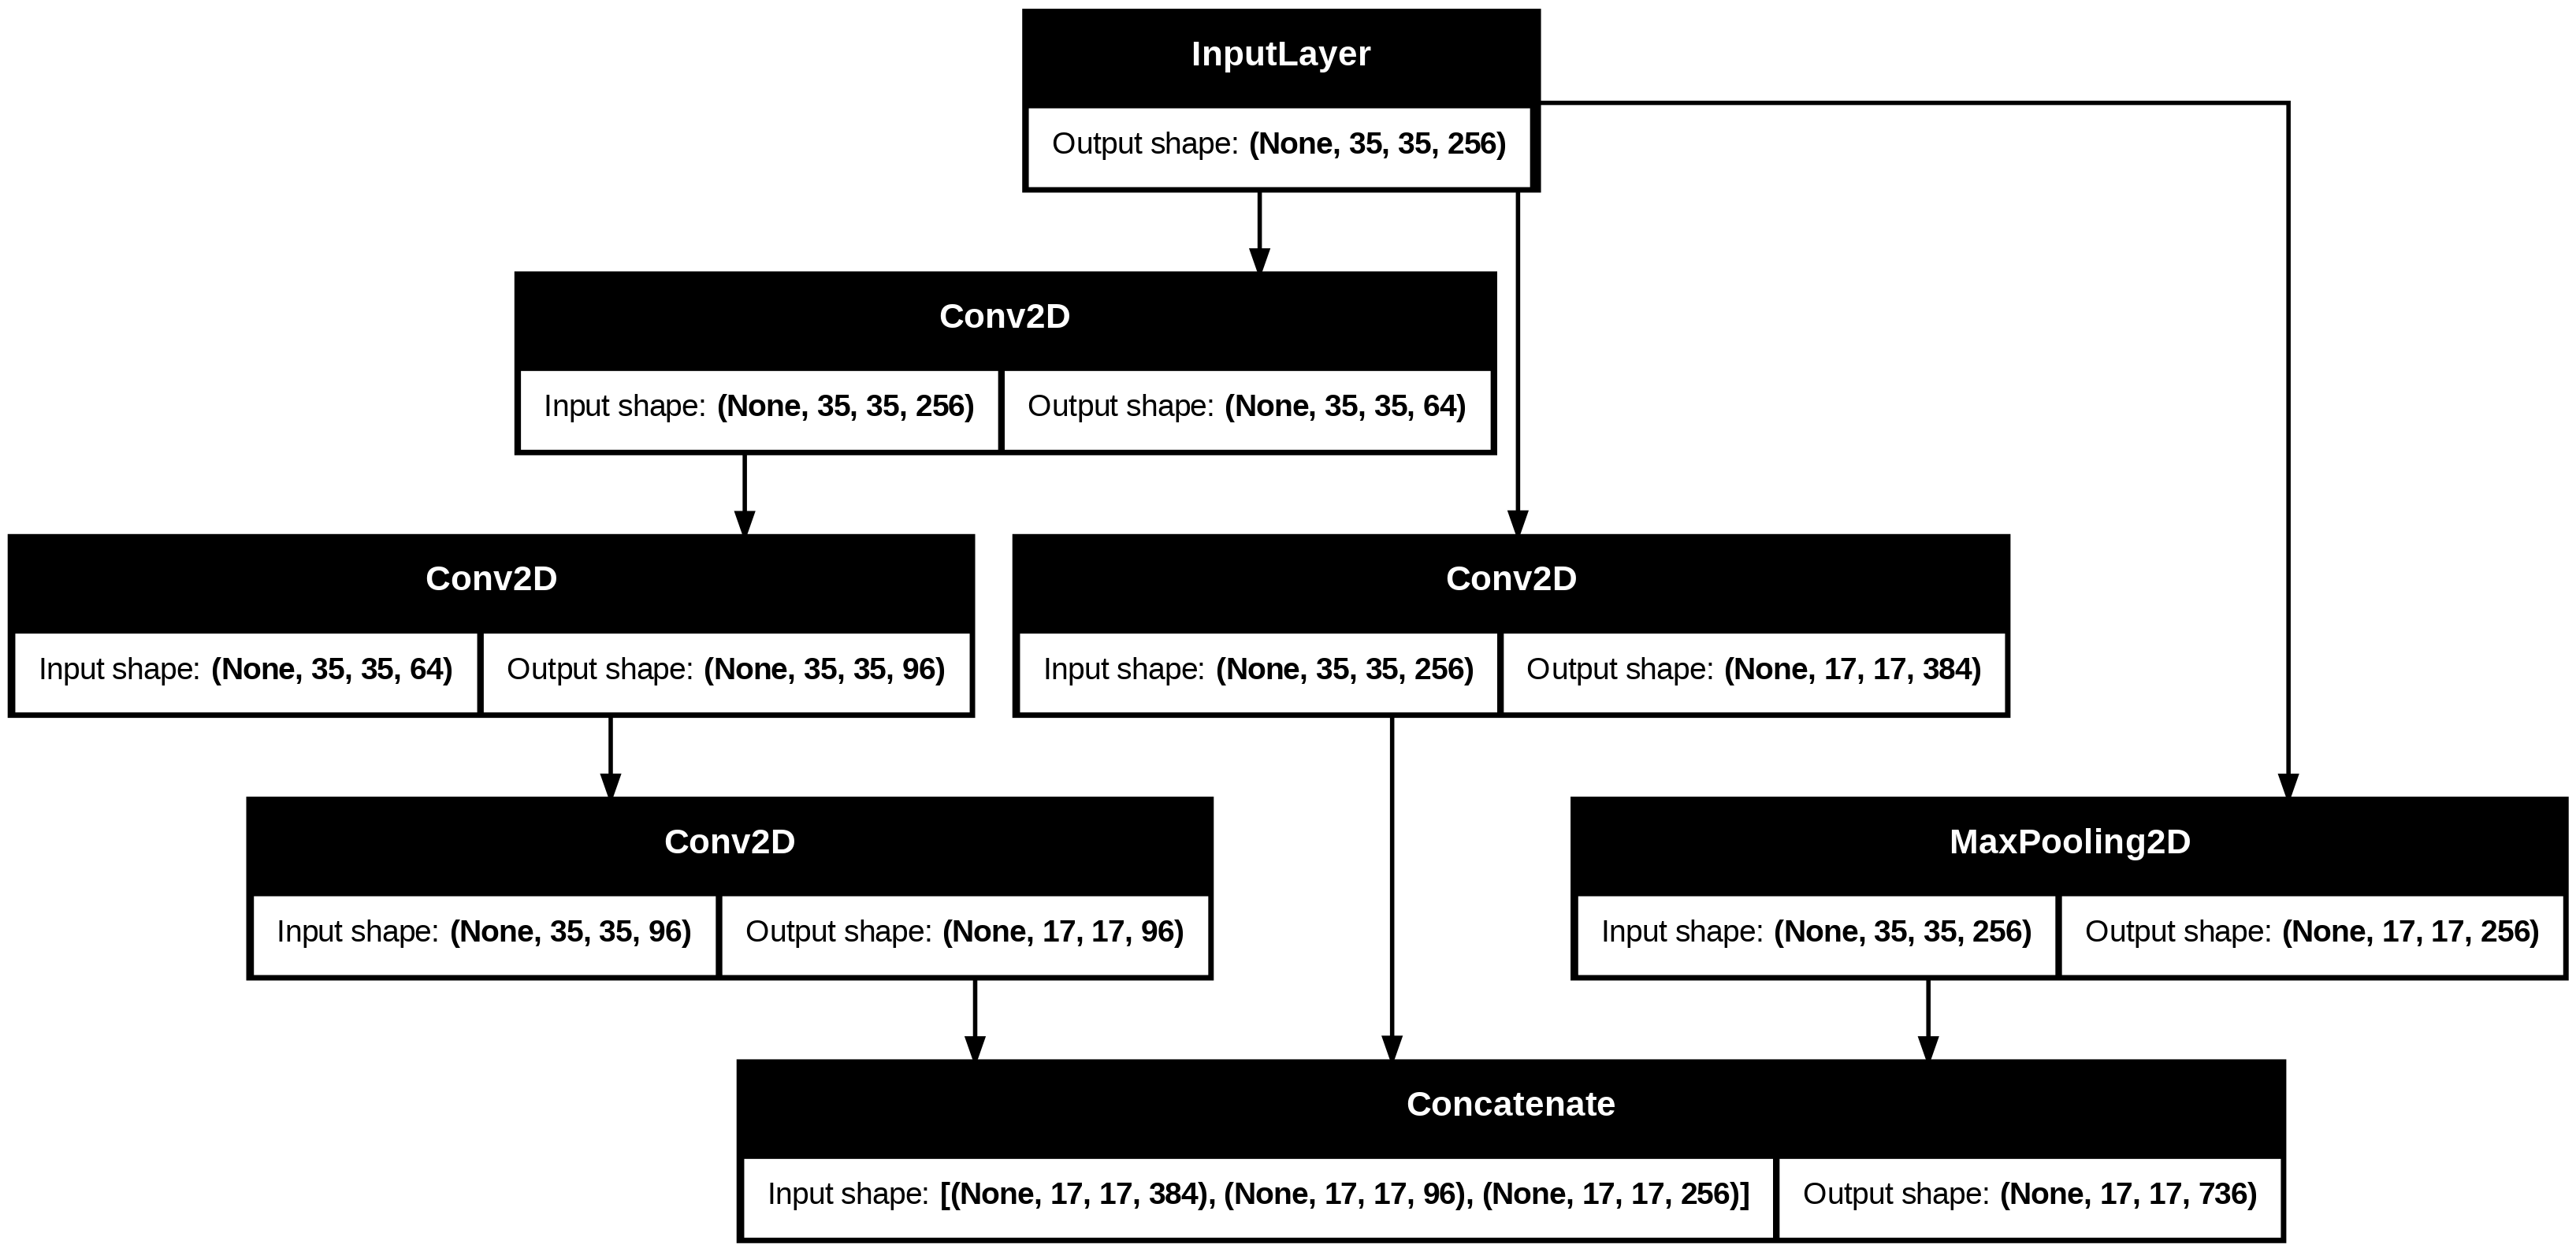

In [31]:
from keras.utils import plot_model
plot_model(model1,show_shapes=True)

# Inception B

In [35]:
l=layers.Input(shape=(17,17,736))
conv1=layers.Conv2D(192,(1,1),padding='same',activation='relu')(l)
conv2=layers.Conv2D(128,(1,1),padding='same',activation='relu')(l)
conv3=layers.Conv2D(128,(1,7),padding='same',activation='relu')(conv2)
conv4=layers.Conv2D(192,(7,1),padding='same',activation='relu')(conv3)
conv5=layers.Conv2D(128,(1,1),padding='same',activation='relu')(l)
conv6=layers.Conv2D(128,(1,7),padding='same',activation='relu')(conv5)
conv7=layers.Conv2D(128,(7,1),padding='same',activation='relu')(conv6)
conv8=layers.Conv2D(128,(1,7),padding='same',activation='relu')(conv7)
conv9=layers.Conv2D(192,(7,1),padding='same',activation='relu')(conv8)
padd1=layers.AveragePooling2D((3,3),strides=1,padding='same')(l)
conv10=layers.Conv2D(192,(1,1),padding='same',activation='relu')(padd1)
output=layers.Concatenate(axis=-1)([conv1,conv4,conv9,conv10])

In [36]:
model2=models.Model(inputs=l,outputs=output)

In [39]:
model2.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 17, 17,    │          0 │ -                 │
│ (InputLayer)        │ 736)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_142 (Conv2D) │ (None, 17, 17,    │     94,336 │ input_layer_11[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_143 (Conv2D) │ (None, 17, 17,    │    114,816 │ conv2d_142[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_139 (Conv2D) │ (None, 17, 17,    │     94,336 │ input_layer_11[0… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_144 (Conv2D) │ (None, 17, 17,    │    114,816 │ conv2d_143[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_140 (Conv2D) │ (None, 17, 17,    │    114,816 │ conv2d_139[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_145 (Conv2D) │ (None, 17, 17,    │    114,816 │ conv2d_144[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 17, 17,    │          0 │ input_layer_11[0… │
│ (AveragePooling2D)  │ 736)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_138 (Conv2D) │ (None, 17, 17,    │    141,504 │ input_layer_11[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_141 (Conv2D) │ (None, 17, 17,    │    172,224 │ conv2d_140[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_146 (Conv2D) │ (None, 17, 17,    │    172,224 │ conv2d_145[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_147 (Conv2D) │ (None, 17, 17,    │    141,504 │ average_pooling2… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 17, 17,    │          0 │ conv2d_138[0][0], │
│ (Concatenate)       │ 768)              │            │ conv2d_141[0][0], │
│                     │                   │            │ conv2d_146[0][0], │
│                     │                   │            │ conv2d_147[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,275,392 (4.87 MB)

 Trainable params: 1,275,392 (4.87 MB)

 Non-trainable params: 0 (0.00 B)

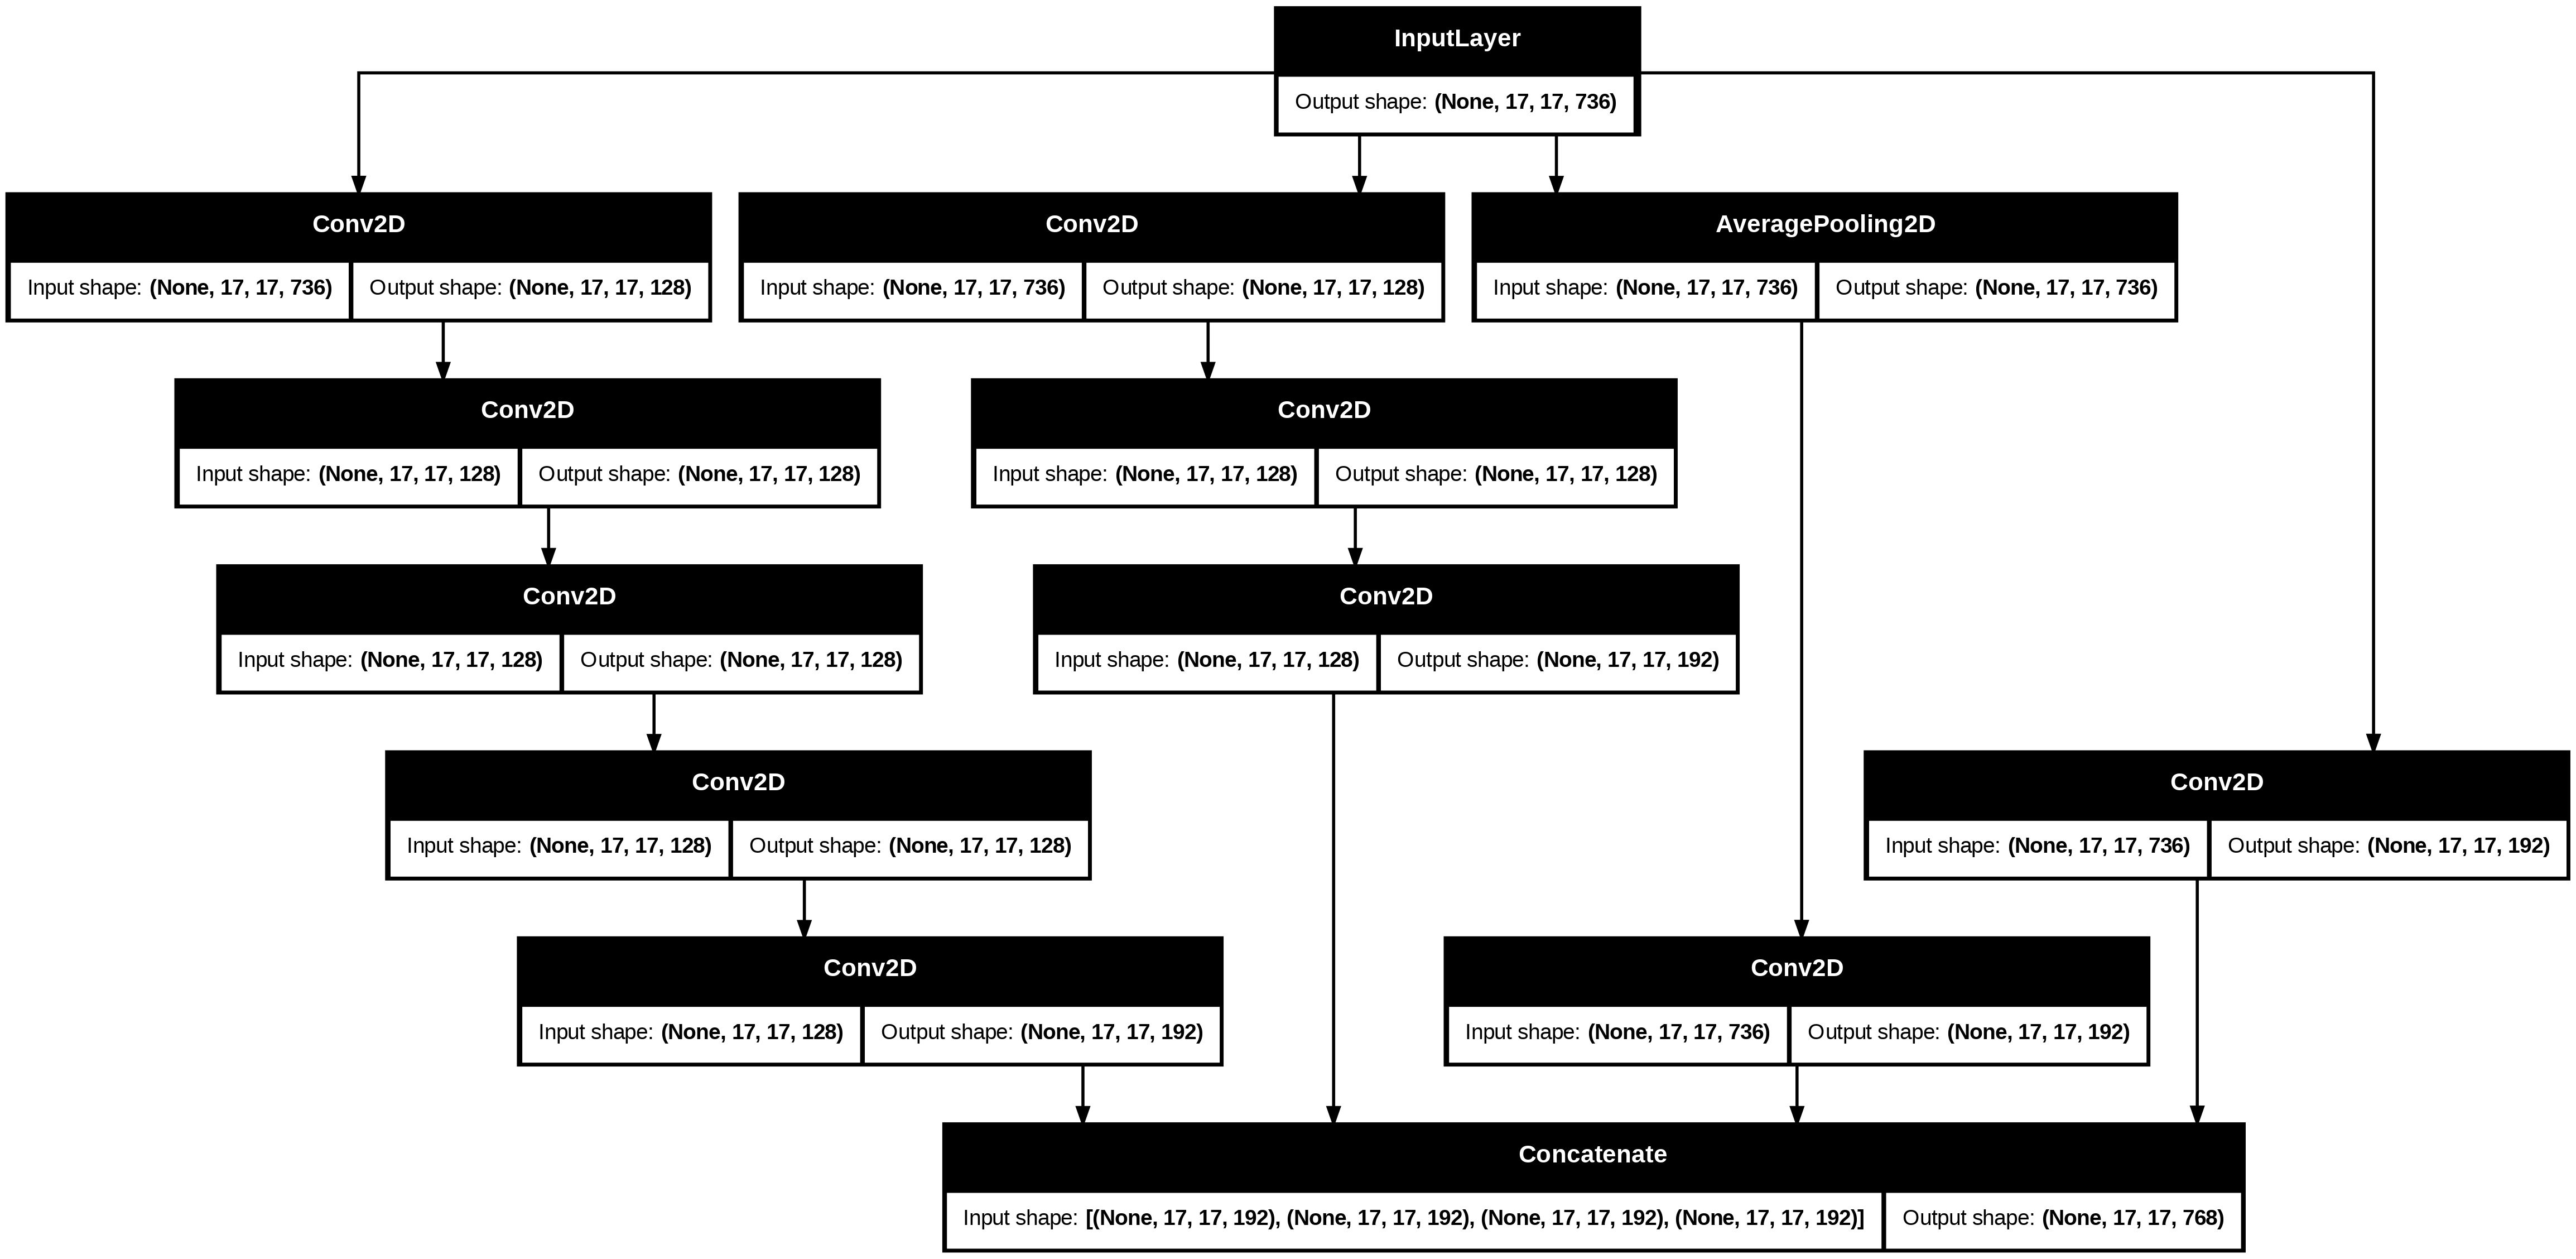

In [38]:
from keras.utils import plot_model
plot_model(model2,show_shapes=True)

In [40]:
def inception_B(x):

    # 🔹 Branch 1
    br1 = conv_bn(x, 192, (1,1))

    # 🔹 Branch 2
    br2 = conv_bn(x, 128, (1,1))
    br2 = conv_bn(br2, 128, (1,7))
    br2 = conv_bn(br2, 192, (7,1))

    # 🔹 Branch 3
    br3 = conv_bn(x, 128, (1,1))
    br3 = conv_bn(br3, 128, (1,7))
    br3 = conv_bn(br3, 128, (7,1))
    br3 = conv_bn(br3, 128, (1,7))
    br3 = conv_bn(br3, 192, (7,1))

    # 🔹 Branch 4
    br4 = layers.AveragePooling2D((3,3), strides=1, padding='same')(x)
    br4 = conv_bn(br4, 192, (1,1))

    # 🔹 Concatenate
    x = layers.Concatenate(axis=-1)([br1, br2, br3, br4])

    return x

# Reduction B

In [50]:
g = layers.Input(shape=(17, 17, 768))
branch1_path = layers.Conv2D(192, (1, 1), activation='relu', padding='same')(g)
branch1_output = layers.Conv2D(320, (3, 3), activation='relu', strides=2, padding='valid')(branch1_path) # Output: (8, 8, 320)
branch2_path = layers.Conv2D(192, (1, 1), activation='relu', padding='same')(g)
branch2_path = layers.Conv2D(192, (1, 7), activation='relu', padding='same')(branch2_path)
branch2_path = layers.Conv2D(192, (7, 1), activation='relu', padding='same')(branch2_path)
branch2_output = layers.Conv2D(192, (3, 3), activation='relu', padding='valid', strides=2)(branch2_path) # Output: (8, 8, 192)
branch3_output = layers.MaxPool2D((3, 3), strides=2, padding='valid')(g) # Output: (8, 8, 768)
output = layers.Concatenate(axis=-1)([branch1_output, branch2_output, branch3_output])

In [51]:
model3=models.Model(inputs=g,outputs=output)

In [52]:
model3.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 17, 17,    │          0 │ -                 │
│ (InputLayer)        │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_294 (Conv2D) │ (None, 17, 17,    │    147,648 │ input_layer_19[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_295 (Conv2D) │ (None, 17, 17,    │    258,240 │ conv2d_294[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_292 (Conv2D) │ (None, 17, 17,    │    147,648 │ input_layer_19[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_296 (Conv2D) │ (None, 17, 17,    │    258,240 │ conv2d_295[0][0]  │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_293 (Conv2D) │ (None, 8, 8, 320) │    553,280 │ conv2d_292[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_297 (Conv2D) │ (None, 8, 8, 192) │    331,968 │ conv2d_296[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 8, 8, 768) │          0 │ input_layer_19[0… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_34      │ (None, 8, 8,      │          0 │ conv2d_293[0][0], │
│ (Concatenate)       │ 1280)             │            │ conv2d_297[0][0], │
│                     │                   │            │ max_pooling2d_20… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,697,024 (6.47 MB)

 Trainable params: 1,697,024 (6.47 MB)

 Non-trainable params: 0 (0.00 B)

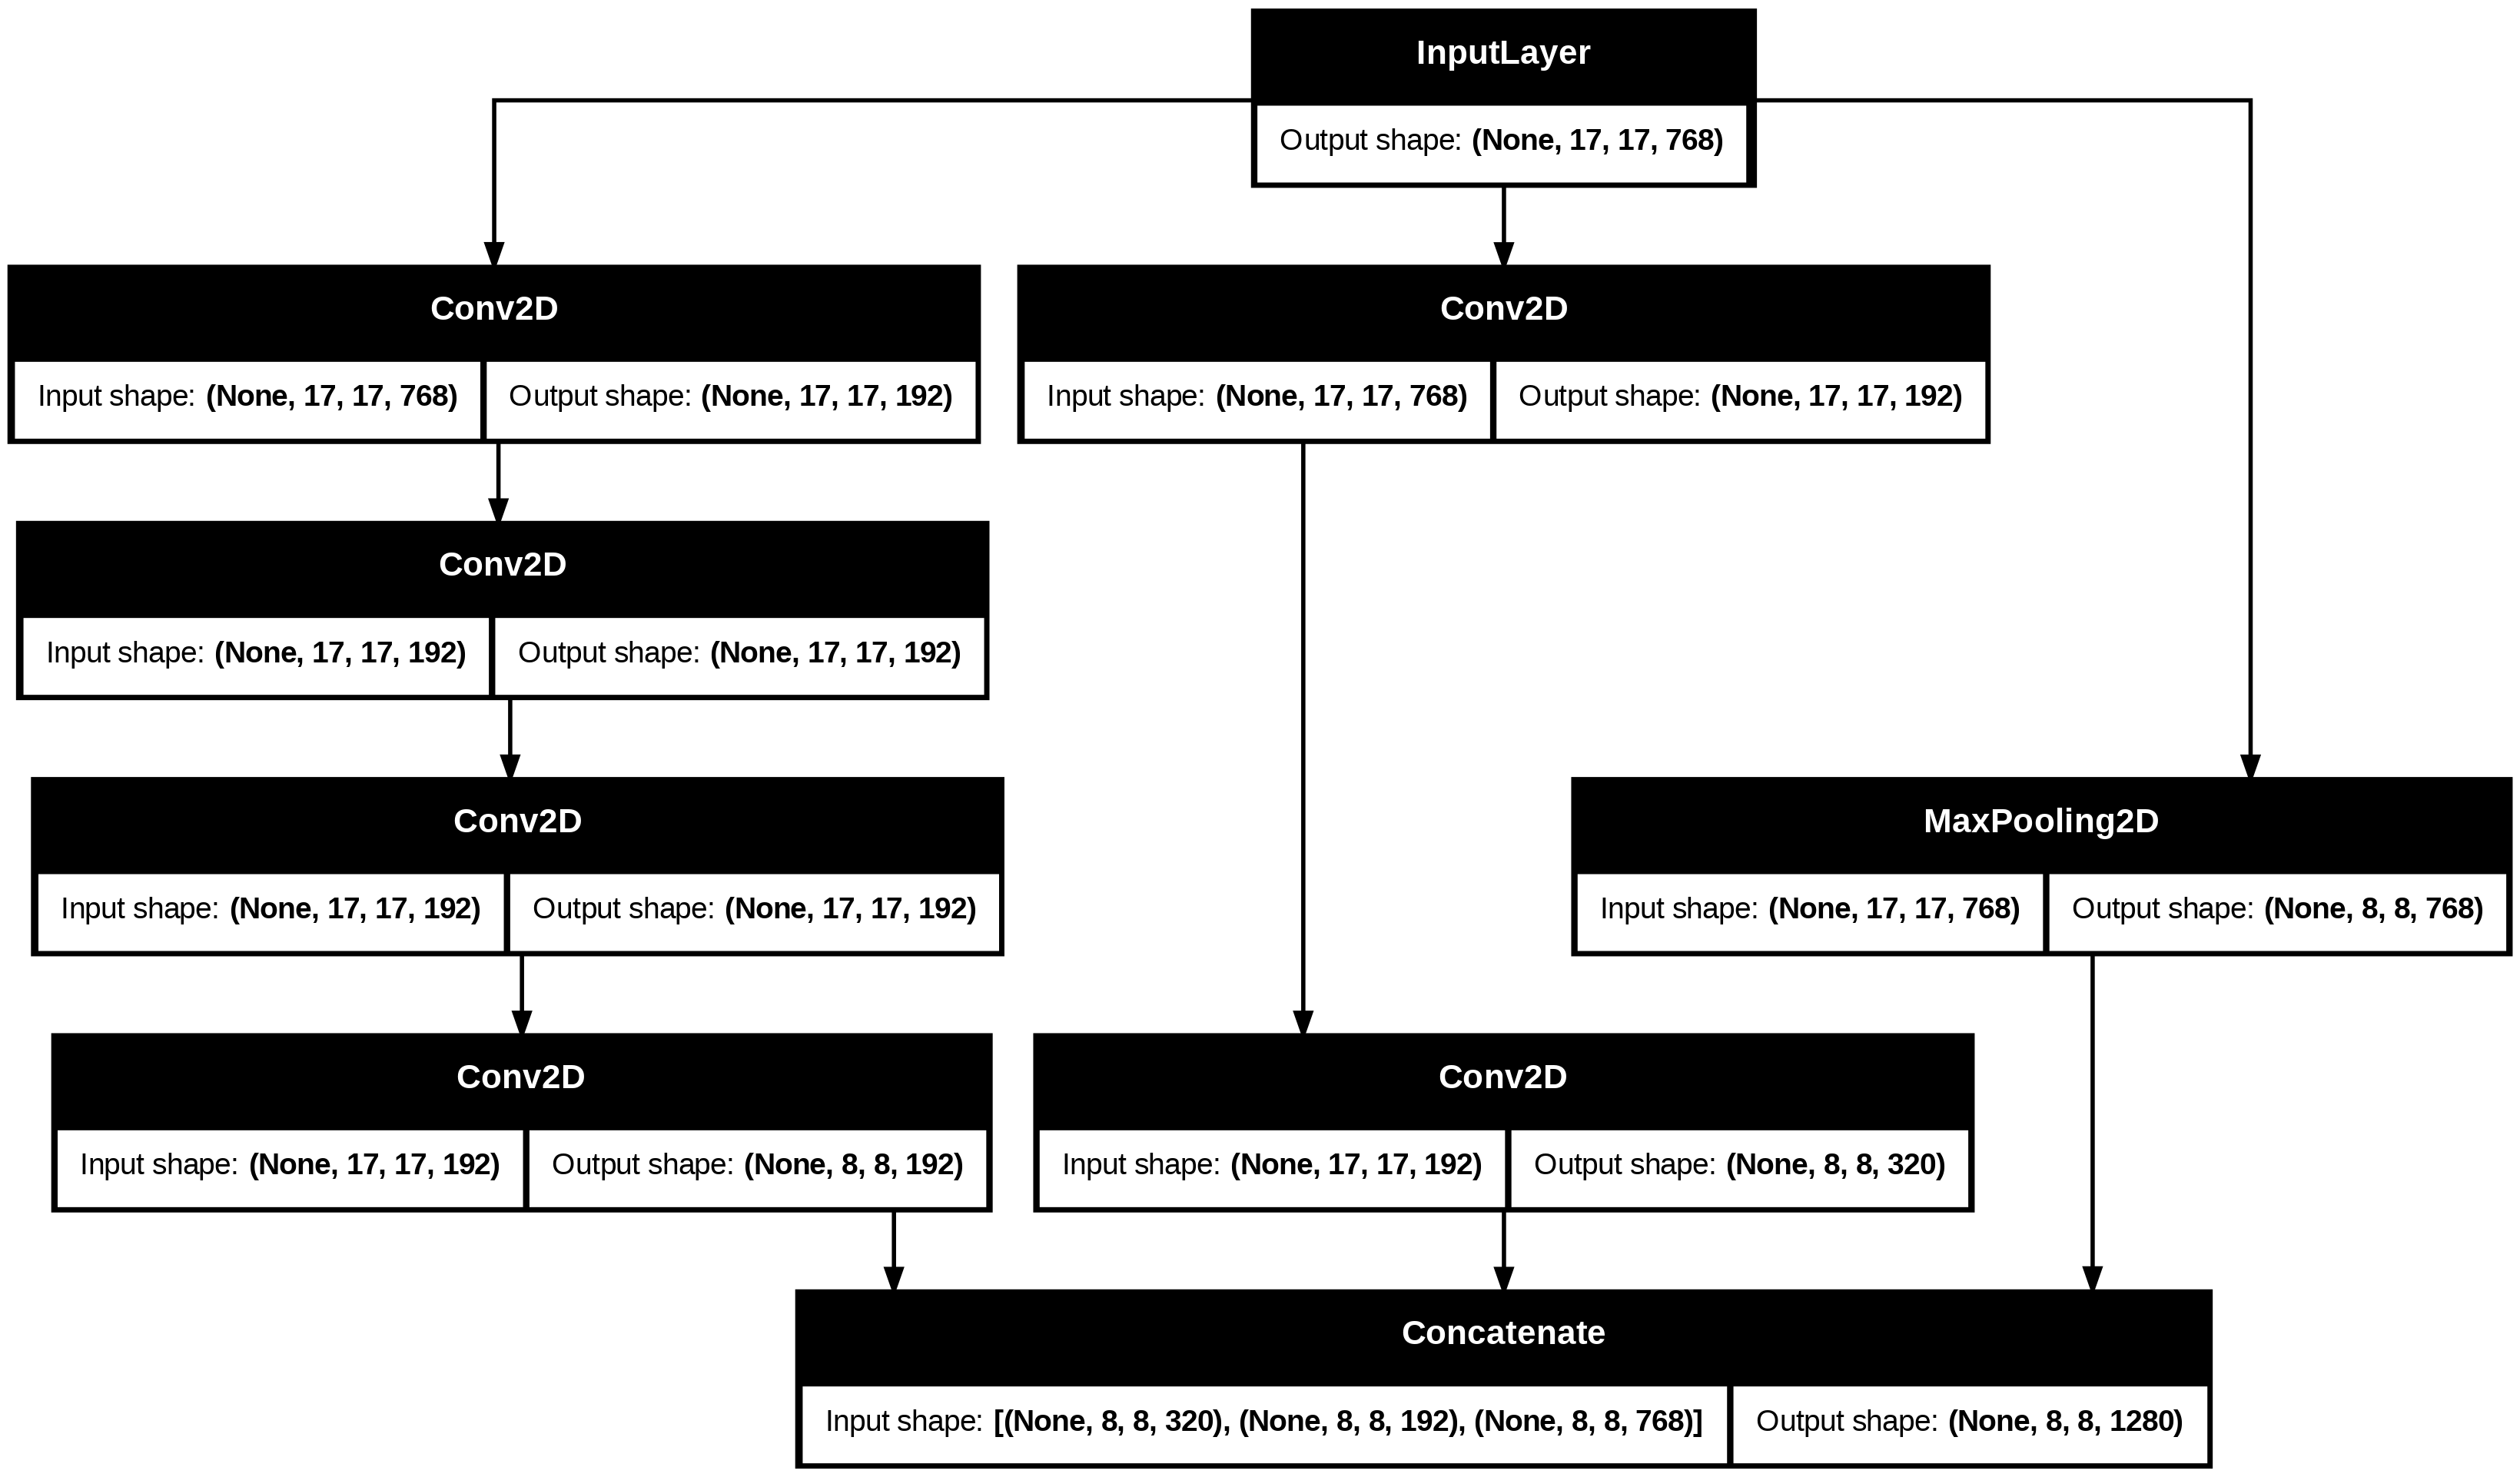

In [53]:
from keras.utils import plot_model
plot_model(model3,show_shapes=True)

In [54]:
def reduction_B(x):

    # 🔹 Branch 1
    br1 = conv_bn(x, 192, (1,1))
    br1 = conv_bn(br1, 320, (3,3), strides=2, padding='valid')

    # 🔹 Branch 2
    br2 = conv_bn(x, 192, (1,1))
    br2 = conv_bn(br2, 192, (1,7))
    br2 = conv_bn(br2, 192, (7,1))
    br2 = conv_bn(br2, 192, (3,3), strides=2, padding='valid')

    # 🔹 Branch 3
    br3 = layers.MaxPooling2D((3,3), strides=2, padding='valid')(x)

    # 🔹 Concatenate
    x = layers.Concatenate(axis=-1)([br1, br2, br3])

    return x

# Inception C

In [61]:
def inception_C(x):


    br1 = conv_bn(x, 320, (1,1))
    br2 = conv_bn(x, 384, (1,1))
    br2_1 = conv_bn(br2, 384, (1,3))
    br2_2 = conv_bn(br2, 384, (3,1))
    br2 = layers.Concatenate(axis=-1)([br2_1, br2_2])
    br3 = conv_bn(x, 448, (1,1))
    br3 = conv_bn(br3, 384, (3,3))
    br3_1 = conv_bn(br3, 384, (1,3))
    br3_2 = conv_bn(br3, 384, (3,1))
    br3 = layers.Concatenate(axis=-1)([br3_1, br3_2])
    br4 = layers.AveragePooling2D((3,3), strides=1, padding='same')(x)
    br4 = conv_bn(br4, 192, (1,1))
    x = layers.Concatenate(axis=-1)([br1, br2, br3, br4])

    return x

# V3

In [62]:
y=layers.Input(shape=(299,299,3))
conv1=layers.Conv2D(32,(3,3),strides=2,padding='valid')(y)
br1=layers.BatchNormalization()(conv1)
conva1=layers.Activation('relu')(br1)
conv2=layers.Conv2D(32,(3,3),strides=1,padding='valid')(conva1)
br2=layers.BatchNormalization()(conv2)
conva2=layers.Activation('relu')(br2)
conv3=layers.Conv2D(64,(3,3),strides=1,padding='same')(conva2)
br3=layers.BatchNormalization()(conv3)
conva3=layers.Activation('relu')(br3)
pool1=layers.MaxPool2D((3,3),strides=2)(conva3)
conv4=layers.Conv2D(80,(1,1),padding='same')(pool1)
br4=layers.BatchNormalization()(conv4)
conva4=layers.Activation('relu')(br4)
conv5=layers.Conv2D(192,(3,3),padding='valid')(conva4)
br5=layers.BatchNormalization()(conv5)
conva5=layers.Activation('relu')(br5)
pool2=layers.MaxPooling2D((3,3),strides=2)(conva5)
x1=inception_A(pool2)
x1=inception_A(x1)
x1=inception_A(x1)
f1=reduction_A(x1)
f2=inception_B(f1)
f3=inception_B(f2)
f4=inception_B(f3)
f5=inception_B(f4)
f6=inception_B(f5)
f7=reduction_B(f6)
f8=inception_C(f7)
f9=inception_C(f8)
f10=inception_C(f9)
f11 = layers.GlobalAveragePooling2D()(f10)
f12 = layers.Dropout(0.5)(f11)
outputs = layers.Dense(100, activation='softmax')(f12)

In [64]:
model=models.Model(inputs=y,outputs=outputs)
model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_497 (Conv2D) │ (None, 149, 149,  │        896 │ input_layer_22[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 149, 149,  │        128 │ conv2d_497[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_401      │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_498 (Conv2D) │ (None, 147, 147,  │      9,248 │ activation_401[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        128 │ conv2d_498[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_402      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_499 (Conv2D) │ (None, 147, 147,  │     18,496 │ activation_402[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        256 │ conv2d_499[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_403      │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 73, 73,    │          0 │ activation_403[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_500 (Conv2D) │ (None, 73, 73,    │      5,200 │ max_pooling2d_29… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        320 │ conv2d_500[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_404      │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_501 (Conv2D) │ (None, 71, 71,    │    138,432 │ activation_404[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        768 │ conv2d_501[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_405      │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 27,470,932 (104.79 MB)

 Trainable params: 27,428,564 (104.63 MB)

 Non-trainable params: 42,368 (165.50 KB)